# Correlation and the Two-Element Interferometer

Convolution, autocorrelation and cross-correlation, and what they have to do
with putting two horn telescopes together.

Written by **Pranav Sanghavi** at the WVU Radio Astronomy Instrumentation
Laboratory, 21 May 2018. Ported from Python 2 to Python 3 in 2026; the plots
gained titles and axis labels, and the interactive widgets became ordinary
figures so the notebook renders the same way everywhere.

Needs `numpy`, `scipy` and `matplotlib` and nothing else:

    pip install numpy scipy matplotlib
    jupyter notebook interferometry.ipynb

Every figure in this notebook is also generated by `make_figures.py`, which is
what the lesson page on the site uses.

> **On the u,v plane.** The original notebook went on to aperture synthesis and
> u,v coverage, working through the excellent
> [Fundamentals of Radio Interferometry](https://github.com/ratt-ru/foi-course)
> course book from Rhodes University and NASSP. That part is not reproduced
> here — it is their material, under their licence, and their book explains it
> better than a copy of it would. Chapter 4, *Visibility Space*, is where to go
> next.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

%matplotlib inline

# The notebook originally asked for the 'seaborn-poster' style. Matplotlib 3.6
# renamed every bundled seaborn style and 3.8 removed the old names, so asking
# for it by name now raises OSError.
for candidate in ("seaborn-v0_8-poster", "seaborn-poster"):
    try:
        plt.style.use(candidate)
        break
    except (OSError, ValueError):
        continue

plt.rcParams.update({
    "font.size": 13.0,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.formatter.limits": (-7, 7),
    "axes.formatter.use_mathtext": True,
})

# Convolution, Auto-correlation and Cross-correlation


## Convolution

"In mathematics (and, in particular, functional analysis) convolution is a mathematical operation on two functions (f and g) to produce a third function, that is typically viewed as a modified version of one of the original functions, giving the integral of the pointwise multiplication of the two functions as a function of the amount that one of the original functions is translated" from wikipedia

$$
(f * g)(x) \,=\, \int_{-\infty}^{+\infty} f(x-t)\,g(t)\,dt
$$

*for multiple dimensions*

$$
\begin{align}
(f * g)(x_1,\ldots,x_n ) \,&=\, (f * g)({\bf x})\\
\,&=\, \int_{-\infty}^{+\infty} \ldots \int_{-\infty}^{+\infty} f(x_1-t_1, \ldots , x_n-t_n)\,g(t_1, \ldots, t_n) \,d^nt\\
\,&=\, \int_{-\infty}^{+\infty} f({\bf x}-{\bf t})\,g({\bf t}) \,d^nt\end{align}
$$

#### Properties of convolution 

$$
\begin{align}
f * g \,&=\, g * f&\qquad (\text{commutativity})\\
(f * g)* h \,&=\, f * (g * h)&\qquad (\text{associativity})\\
f * (g + h) \,&=\, (f * g) + (f * h) &\qquad (\text{distributivity})\\
(a\, g) * h \,&=\, a \, (g * h)&\qquad (\text{associativity with scalar multiplication})\\
\end{align}
$$

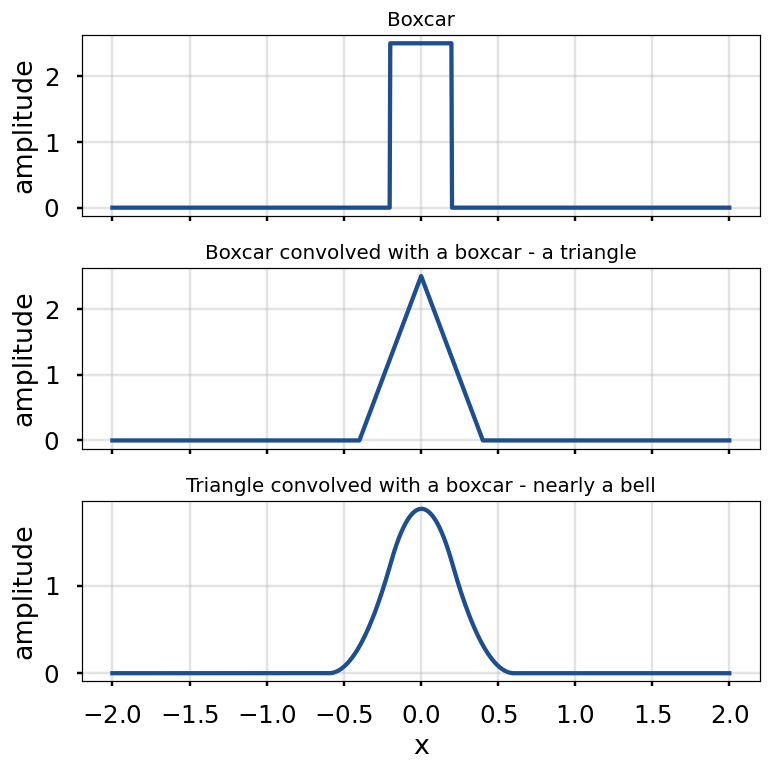

In [2]:
def boxcar(x, a, b, amp):
    """A rectangle of height `amp` between a and b."""
    return amp * np.logical_and(x >= a, x <= b)

a, b = -0.2, 0.2
xrange = [-2.0, 2.0]
xpoints = 1000
dx = (xrange[1] - xrange[0]) / float(xpoints)
x = np.linspace(xrange[0], xrange[1], xpoints)

# normalise to unit area so the three panels are comparable
y = boxcar(x, a, b, 1.0)
amp = float(xpoints) / ((xrange[1] - xrange[0]) * y.sum())
y = boxcar(x, a, b, amp)

once = dx * np.convolve(y, y, "same")
twice = dx * np.convolve(once, y, "same")

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(7.2, 7.2))
for ax, data, title in zip(
        axes, (y, once, twice),
        ("Boxcar",
         "Boxcar convolved with a boxcar - a triangle",
         "Triangle convolved with a boxcar - nearly a bell")):
    ax.plot(x, data, "-", color="#1f4e8c")
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("amplitude")
axes[-1].set_xlabel("x")
fig.tight_layout()

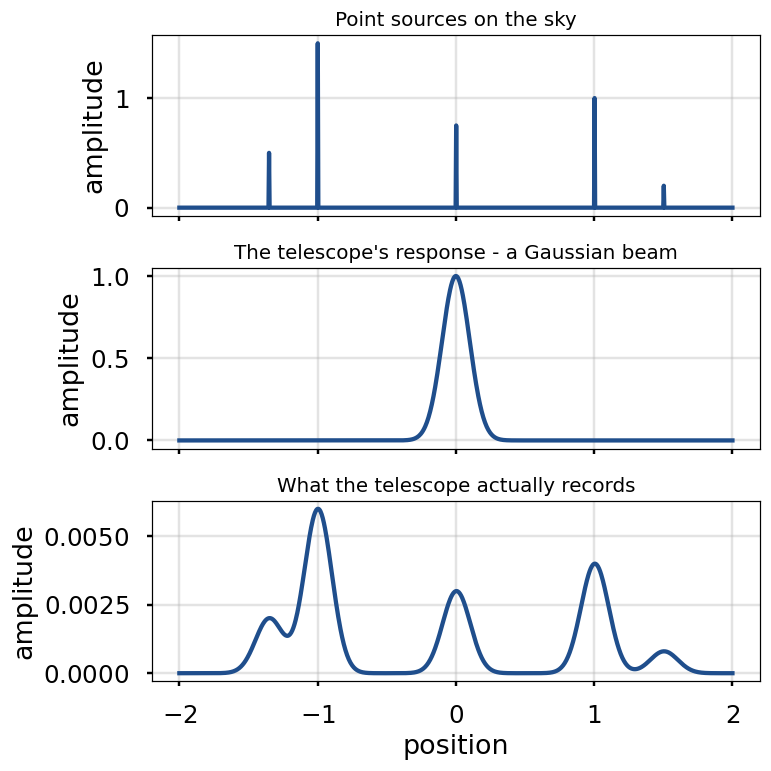

In [3]:
def gaussian(x, amp, mu, sigma):
    y = (x - mu) / sigma
    return amp * np.exp(-np.power(y, 2.0) / 2)

sigma = 0.1

def at(x0):
    """Index of position x0 in the x array."""
    return int((x0 - xrange[0]) / dx)

spikes = (signal.unit_impulse(xpoints, [at(-1.0), at(0.0), at(1.0)])
          + 0.20 * signal.unit_impulse(xpoints, at(1.50))
          - 0.25 * signal.unit_impulse(xpoints, "mid")
          + 0.50 * signal.unit_impulse(xpoints, at(-1.00))
          + 0.50 * signal.unit_impulse(xpoints, at(-1.35)))

kernel = gaussian(x, 1.0, 0.0, sigma)
smoothed = dx * np.convolve(spikes, kernel, "same")

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(7.2, 7.2))
for ax, data, title in zip(
        axes, (spikes, kernel, smoothed),
        ("Point sources on the sky",
         "The telescope's response - a Gaussian beam",
         "What the telescope actually records")):
    ax.plot(x, data, "-", color="#1f4e8c")
    ax.set_title(title, fontsize=13)
    ax.set_ylabel("amplitude")
axes[-1].set_xlabel("position")
fig.tight_layout()

## Cross-correlation


$$
\begin{split}
(f\star g)(x) \,&=\, ({f_-}^*\circ g)(x)\\
&=\, \int_{-\infty}^{+\infty} f^*(t-x)\,g(t)\,dt\\
&\underset{t^\prime = t-x}{=}\, \int_{-\infty}^{+\infty} f^*(t^\prime)\,g(t^\prime+x)\,dt^\prime\\
\end{split}\qquad \text{,}
$$

$$
\begin{align}
(f\star g)(x_1,\ldots,x_n ) \,&=\, (f\star g)({\bf x})\\
&=\, ({f_-}^*\circ g)(x)\\
&=\, \int_{-\infty}^{+\infty} \ldots \int_{-\infty}^{+\infty} f^*(t_1-x_1, \ldots , t_n-x_n)\,g(t_1, \ldots, t_n) \,d^nt\\
\end{align}
$$


## Autocorrelation
$$
\begin{split}
R\{f\}(x) \,&=\, (f\star f)(x)\\
&=\, (f_-^* * f)(x)\\
&=\, \int_{-\infty}^{+\infty} f^*(t-x)\,f(t)\,dt\\
&\underset{t^\prime = t-x}{=}\, \int_{-\infty}^{+\infty} f^*(t^\prime)\,f(t^\prime+x)\,dt^\prime\\
\end{split}\qquad \text{.}
$$

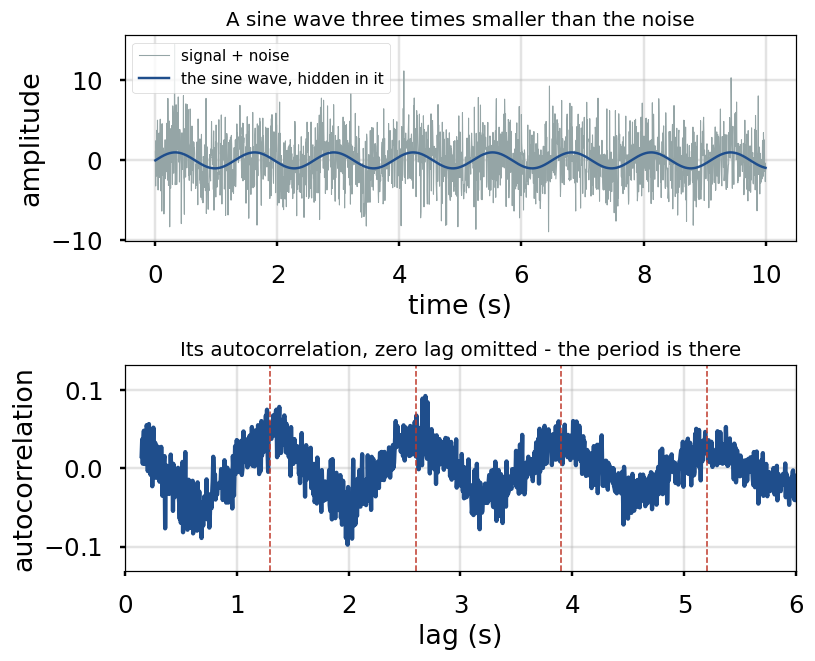

In [4]:
# Autocorrelation finds a periodicity you cannot see by eye.
rng = np.random.default_rng(20180521)
t = np.linspace(0, 10, 2000)
period = 1.3
clean = np.sin(2 * np.pi * t / period)
noisy = clean + rng.normal(0, 3.0, t.size)

ac = np.correlate(noisy, noisy, "full")[noisy.size - 1:]
ac = ac / ac[0]
lag = t - t[0]

fig, axes = plt.subplots(2, 1, figsize=(7.6, 6.2))
axes[0].plot(t, noisy, lw=0.7, color="#95a5a6", label="signal + noise")
axes[0].plot(t, clean, lw=1.6, color="#1f4e8c", label="the sine wave, hidden in it")
axes[0].set_xlabel("time (s)"); axes[0].set_ylabel("amplitude")
axes[0].set_title("A sine wave three times smaller than the noise", fontsize=13)
axes[0].legend(fontsize=10)

# Skip the zero-lag spike: it is 1.0 by construction and squashes everything
# that carries the information into the bottom of the panel.
keep = (lag >= 0.15) & (lag <= 6.0)
axes[1].plot(lag[keep], ac[keep], color="#1f4e8c")
for k in range(1, 5):
    axes[1].axvline(k * period, color="#c0392b", ls="--", lw=1)
span = np.abs(ac[keep]).max() * 1.35
axes[1].set_ylim(-span, span); axes[1].set_xlim(0, 6)
axes[1].set_xlabel("lag (s)"); axes[1].set_ylabel("autocorrelation")
axes[1].set_title("Its autocorrelation, zero lag omitted - the period is there",
                  fontsize=13)
fig.tight_layout()

### Why Interferometry

In [5]:
HI_WAVELENGTH = 0.21   # m, the 21 cm line

def dish_diameter(angres_deg, wavelength=HI_WAVELENGTH):
    """Diameter needed for a given angular resolution, circular aperture."""
    return 1.22 * wavelength / np.radians(angres_deg)

for arcsec, what in [(3600.0, "1 degree"), (60.0, "1 arcmin"),
                     (1.0, "1 arcsec"), (0.015, "15 milliarcsec, the VLA")]:
    d = dish_diameter(arcsec / 3600.0)
    print("%-26s needs a dish %10.1f m across" % (what, d))

print("\nThe Earth is 12,742,000 m across.")

1 degree                   needs a dish       14.7 m across
1 arcmin                   needs a dish      880.8 m across
1 arcsec                   needs a dish    52845.0 m across
15 milliarcsec, the VLA    needs a dish  3523002.9 m across

The Earth is 12,742,000 m across.


# 2 element interferometer

We can combine these signals:
* by addition to form a *sum* interferometer, or $\sum$-interferometer
* by multiplication to form a *product* interferometer, or $\prod$-interferometer.

## The $\sum$-interferometer

$$P ={2 V_0^2(1+ \cos\Delta \Phi)} $$

## The $\prod$-interferometer 

$$R_c= \langle V_1 V_2 \rangle_t$$ 
$$R_c =\frac{V_0^2}{2}\cos{\omega \tau}=\frac{V_0^2}{2}\cos \Delta \Phi$$ where $\tau$ is the time delay in the signal path


This is a cosine correlator, one can consider a sine correlator by introducing an artificial phase delay of $\frac{\pi}{2}$ in one of the two signal paths:

$$V_1=V_{01} \cos (\omega (t + \tau))  \quad V_2 = V_{02} \cos (\omega t + \frac{\pi}{2} )$$

\begin{eqnarray}
R&=&\langle V_{01} V_{02} \cos{(\omega t + \frac{\pi}{2})} \cos{[\omega (t + \tau) ]} \rangle_t\\
R&=& V_0^2 \frac{\langle \cos(2 \omega t + \tau + \frac{\pi}{2})+\cos (\omega \tau - \frac{\pi}{2})\rangle_t}{2}
\end{eqnarray}
$$R_s =\frac{V_0^2}{2}\sin{\omega \tau}$$


we can combine the two operations to obtain a complex correlator 

$$R = \int_{\Omega}  I_\nu(\mathbf{s}) e^{-\imath 2\pi \frac{\mathbf{b}\cdot\mathbf{s}}{\lambda}} d\Omega = V$$

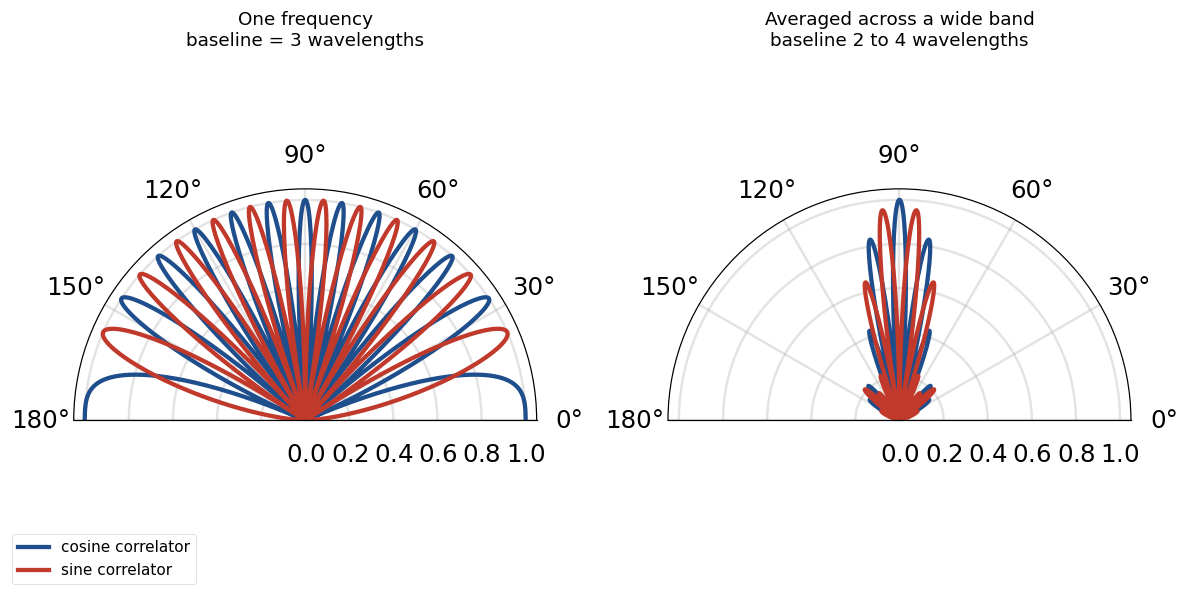

In [6]:
theta = np.linspace(0.0, 180.0, 1000)

# a single frequency, baseline three wavelengths long
single = np.exp(-1j * 2 * np.pi * 3.0 * np.cos(np.radians(theta)))

# the same baseline seen across a wide band, 2 to 4 wavelengths
blambda = np.linspace(2.0, 4.0, 100)
wide = np.zeros_like(theta, dtype=complex)
for bl in blambda:
    wide += np.exp(-1j * 2 * np.pi * bl * np.cos(np.radians(theta)))

single = single / np.abs(single).max()
wide = wide / np.abs(wide).max()

fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.4),
                         subplot_kw={"projection": "polar"})
for ax, data, title in zip(
        axes, (single, wide),
        ("One frequency\nbaseline = 3 wavelengths",
         "Averaged across a wide band\nbaseline 2 to 4 wavelengths")):
    ax.plot(np.radians(theta), np.abs(np.real(data)),
            color="#1f4e8c", label="cosine correlator")
    ax.plot(np.radians(theta), np.abs(np.imag(data)),
            color="#c0392b", label="sine correlator")
    ax.set_title(title, fontsize=12, pad=18)
    ax.set_thetamin(0); ax.set_thetamax(180)
axes[0].legend(loc="lower left", bbox_to_anchor=(-0.15, -0.12), fontsize=10)
fig.tight_layout()

## Effect of Bandwidth

## Credits and reuse

The text and code above are Pranav Sanghavi's, written for the WVU Radio
Astronomy Instrumentation Laboratory in 2018, and are published here under the
same MIT licence as the rest of this repository. The autocorrelation figure was
added in 2026; everything else is his.

The Wikipedia definition of convolution quoted at the top is used under
CC BY-SA 4.0.

For aperture synthesis, u,v coverage and everything that follows from two
elements to an array, go to
[Fundamentals of Radio Interferometry](https://github.com/ratt-ru/foi-course)
(Rhodes University / NASSP, GPL v2) — chapter 4 in particular. It is free to
read online and is the standard text for this material.
